In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression # Added this import

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report

In [13]:
# Creating sample flight dataset

data = {
    "Airline": [
        "AirIndia","Emirates","Indigo",
        "SpiceJet","Vistara","AirIndia",
        "Emirates","Indigo","SpiceJet",
        "Vistara"
    ],

    "Distance":[
        1200,3000,800,
        600,1500,2000,
        3500,900,700,
        1700
    ],

    "Departure_Hour":[
        8,14,18,
        10,20,6,
        22,12,16,
        9
    ],

    "Weather":[
        "Rain","Clear","Storm",
        "Clear","Rain","Clear",
        "Storm","Clear","Rain",
        "Clear"
    ],

    "Previous_Delay":[
        "Yes","No","Yes",
        "No","Yes","No",
        "Yes","No","Yes",
        "No"
    ],

    "Delayed":[
        1,0,1,
        0,1,0,
        1,0,1,
        0
    ]
}


df = pd.DataFrame(data)

df

,Airline,Distance,Departure_Hour,Weather,Previous_Delay,Delayed
0,AirIndia,1200,8,Rain,Yes,1
1,Emirates,3000,14,Clear,No,0
2,Indigo,800,18,Storm,Yes,1
3,SpiceJet,600,10,Clear,No,0
4,Vistara,1500,20,Rain,Yes,1
5,AirIndia,2000,6,Clear,No,0
6,Emirates,3500,22,Storm,Yes,1
7,Indigo,900,12,Clear,No,0
8,SpiceJet,700,16,Rain,Yes,1
9,Vistara,1700,9,Clear,No,0


In [14]:
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Airline         10 non-null     object
 1   Distance        10 non-null     int64 
 2   Departure_Hour  10 non-null     int64 
 3   Weather         10 non-null     object
 4   Previous_Delay  10 non-null     object
 5   Delayed         10 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 612.0+ bytes

Missing Values:
Airline           0
Distance          0
Departure_Hour    0
Weather           0
Previous_Delay    0
Delayed           0
dtype: int64


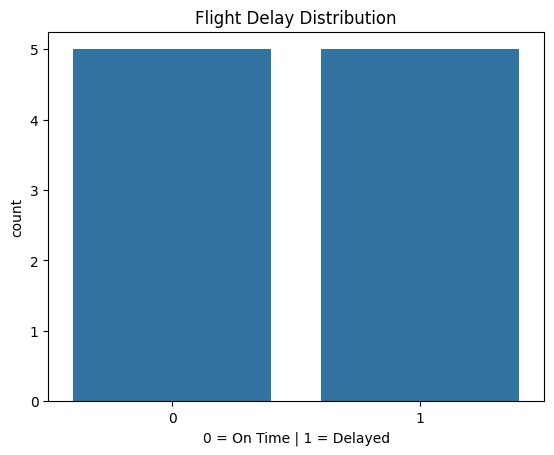

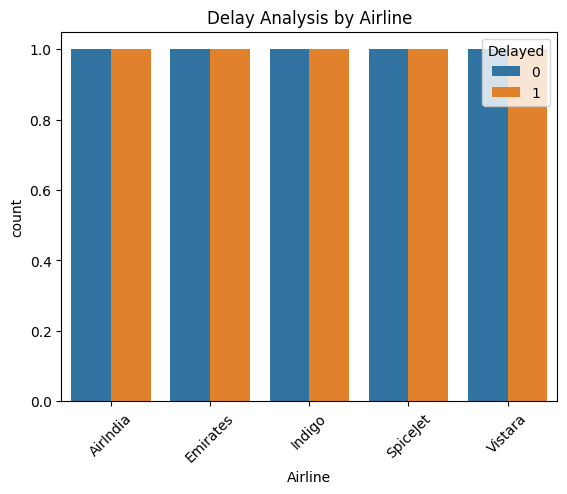

In [15]:
sns.countplot(
    x="Delayed",
    data=df
)

plt.title(
    "Flight Delay Distribution"
)

plt.xlabel(
    "0 = On Time | 1 = Delayed"
)

plt.show()
sns.countplot(
    x="Airline",
    hue="Delayed",
    data=df
)

plt.xticks(rotation=45)

plt.title(
    "Delay Analysis by Airline"
)

plt.show()

In [16]:
encoder = LabelEncoder()


for column in df.select_dtypes(include="object"):
    df[column] = encoder.fit_transform(df[column])


df.head()

,Airline,Distance,Departure_Hour,Weather,Previous_Delay,Delayed
0,0,1200,8,1,1,1
1,1,3000,14,0,0,0
2,2,800,18,2,1,1
3,3,600,10,0,0,0
4,4,1500,20,1,1,1


In [17]:
X = df.drop(
    "Delayed",
    axis=1
)

y = df["Delayed"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
log_model = LogisticRegression()


log_model.fit(
    X_train,
    y_train
)


log_prediction = log_model.predict(
    X_test
)


log_accuracy = accuracy_score(
    y_test,
    log_prediction
)


print(
    "Logistic Regression Accuracy:",
    log_accuracy
)

Logistic Regression Accuracy: 0.5


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


rf_model.fit(
    X_train,
    y_train
)


rf_prediction = rf_model.predict(
    X_test
)


rf_accuracy = accuracy_score(
    y_test,
    rf_prediction
)


print(
    "Random Forest Accuracy:",
    rf_accuracy
)

Random Forest Accuracy: 1.0


In [20]:
models = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy":[
        log_accuracy,
        rf_accuracy
    ]
})


models

,Model,Accuracy
0,Logistic Regression,0.5
1,Random Forest,1.0


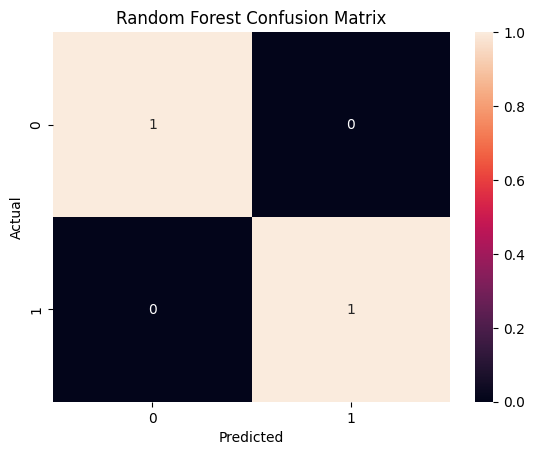

In [21]:
cm = confusion_matrix(
    y_test,
    rf_prediction
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)


plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Random Forest Confusion Matrix"
)


plt.show()

In [22]:
print(
    classification_report(
        y_test,
        rf_prediction
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [23]:
# New flight details

new_flight = pd.DataFrame({

    "Airline":[0],
    "Distance":[2500],
    "Departure_Hour":[15],
    "Weather":[1],
    "Previous_Delay":[1]

})


prediction = rf_model.predict(
    new_flight
)


if prediction[0]==1:

    print(
        "❌ Flight is likely to be DELAYED"
    )

else:

    print(
        "✅ Flight is likely to be ON TIME"
    )

❌ Flight is likely to be DELAYED


In [24]:
import pickle


pickle.dump(
    rf_model,
    open(
        "flight_delay_model.pkl",
        "wb"
    )
)


print(
    "Model saved successfully"
)

Model saved successfully
